# Proyecto 1 — Competencia de Modelación (MLP)
**CC3092 · Deep Learning y Sistemas Inteligentes** · Universidad del Valle de Guatemala
**Autor:** Nicolás Concuá

Predicción del precio de venta de viviendas (`SalePrice`) del dataset **House Prices / Ames**
mediante un **Multi-Layer Perceptron (MLP)**. Métrica objetivo: **RMSE**.

Este notebook cubre el análisis exploratorio de datos (EDA) y, en secciones
posteriores, el preprocesamiento, la búsqueda de hiperparámetros y el entrenamiento
del modelo final.

## 0. Configuración del entorno

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # para importar mlp_core.py

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "../data/train.csv"
FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, name), bbox_inches="tight", dpi=130)

df = pd.read_csv(DATA_PATH)
print("Dataset cargado:", df.shape)
df.head()

Dataset cargado: (1168, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


## 1. Análisis exploratorio de datos (EDA)

### 1.1 Dimensiones, tipos de variables y variable objetivo

In [2]:
print(f"Observaciones: {df.shape[0]}  |  Columnas: {df.shape[1]}")
print(f"Columna identificadora: 'Id'  |  Variable objetivo: 'SalePrice'")

# Separamos features numéricas y categóricas (excluyendo Id y target)
num_cols = df.select_dtypes(include=[np.number]).columns.drop(["Id", "SalePrice"]).tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nFeatures numéricas:   {len(num_cols)}")
print(f"Features categóricas: {len(cat_cols)}")

pd.DataFrame({"tipo": df.dtypes.astype(str)}).T

Observaciones: 1168  |  Columnas: 81
Columna identificadora: 'Id'  |  Variable objetivo: 'SalePrice'

Features numéricas:   36
Features categóricas: 43


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
tipo,int64,int64,str,float64,int64,str,str,str,str,str,...,int64,str,str,str,int64,int64,int64,str,str,int64


**Respuesta.** El dataset de entrenamiento tiene **1,168 observaciones** y **81 columnas**:
`Id`, la variable objetivo `SalePrice` y **79 features** predictoras, divididas en
**36 numéricas** y **43 categóricas**. Las categóricas incluyen variables nominales
(p. ej. `Neighborhood`, `MSZoning`) y ordinales codificadas como texto (p. ej. calidades
`ExterQual`, `KitchenQual` con niveles Po/Fa/TA/Gd/Ex). La variable objetivo es
**continua** (precio en dólares) → se trata de un problema de **regresión**.

### 1.2 Variable objetivo: `SalePrice`

,count,mean,std,min,25%,50%,75%,max
SalePrice,1168.0,181442.0,77264.0,34900.0,130000.0,165000.0,214925.0,745000.0


Asimetría (skew) SalePrice:        1.743
Asimetría (skew) log1p(SalePrice): 0.125


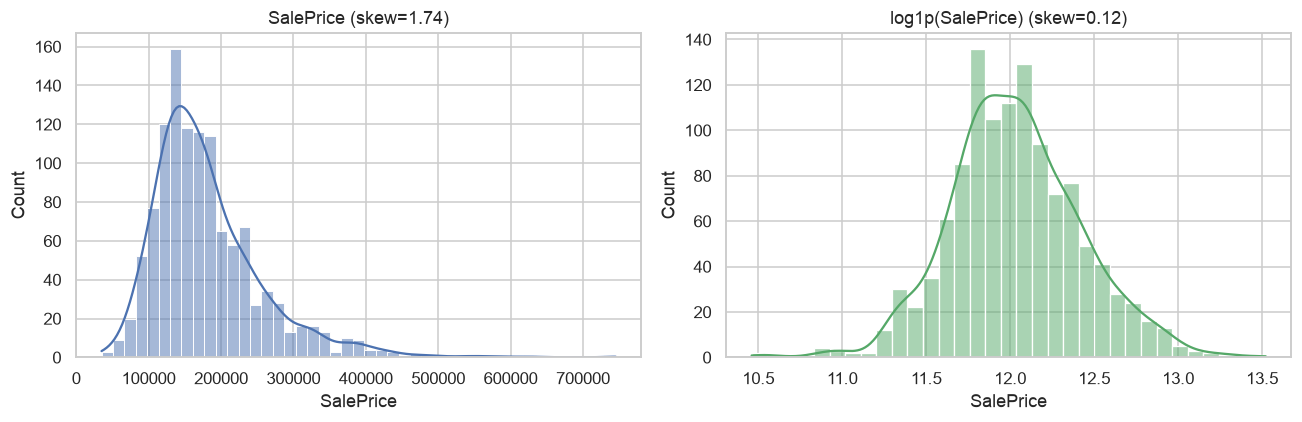

In [3]:
display(df["SalePrice"].describe().round(0).to_frame().T)

skew_raw = df["SalePrice"].skew()
skew_log = np.log1p(df["SalePrice"]).skew()
print(f"Asimetría (skew) SalePrice:        {skew_raw:.3f}")
print(f"Asimetría (skew) log1p(SalePrice): {skew_log:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["SalePrice"], kde=True, ax=ax[0], color="#4C72B0")
ax[0].set_title(f"SalePrice (skew={skew_raw:.2f})")
sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=ax[1], color="#55A868")
ax[1].set_title(f"log1p(SalePrice) (skew={skew_log:.2f})")
savefig("01_target_distribution.png")
plt.show()

**Respuesta.** `SalePrice` va de **\$34,900** a **\$745,000**, con media **\$181,442**
y mediana **\$165,000**. La distribución está **fuertemente sesgada a la derecha**
(skew = **1.74**): hay una cola larga de viviendas caras. Al aplicar `log1p`, la
distribución se vuelve **casi simétrica** (skew = **0.13**).

> **Decisión de modelado:** entrenaremos el MLP sobre **`log1p(SalePrice)`** e
> invertiremos las predicciones con `expm1`. Esto estabiliza la varianza, evita que
> las casas caras dominen la pérdida y suele mejorar el RMSE en este dataset.

## 2. Estadísticas descriptivas de las variables relevantes

In [4]:
# Estadísticos de las numéricas más correlacionadas con el target
corr_target = (df[num_cols + ["SalePrice"]].corr()["SalePrice"]
               .drop("SalePrice").sort_values(ascending=False))
top_num = corr_target.head(8).index.tolist()
df[top_num + ["SalePrice"]].describe().loc[["mean","std","min","50%","max"]].round(1)

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,SalePrice
mean,6.1,1527.4,1.8,476.3,1061.8,1169.4,1.6,6.6,181441.5
std,1.4,524.4,0.7,211.1,440.7,386.7,0.5,1.6,77263.6
min,1.0,334.0,0.0,0.0,0.0,334.0,0.0,2.0,34900.0
50%,6.0,1473.0,2.0,482.0,997.5,1095.0,2.0,6.0,165000.0
max,10.0,5642.0,4.0,1418.0,6110.0,4692.0,3.0,14.0,745000.0


In [5]:
# Variables categóricas: número de niveles (cardinalidad)
card = df[cat_cols].nunique().sort_values(ascending=False)
print("Cardinalidad de las categóricas (nº de niveles):")
display(card.to_frame("niveles").T)
print(f"Total de niveles sumados: {card.sum()} → tamaño aproximado tras One-Hot.")

Cardinalidad de las categóricas (nº de niveles):


,Neighborhood,Exterior2nd,Exterior1st,SaleType,Condition1,Condition2,HouseStyle,Functional,RoofMatl,BsmtFinType2,...,BsmtExposure,LandSlope,GarageFinish,MasVnrType,PavedDrive,PoolQC,Utilities,CentralAir,Alley,Street
niveles,25,16,15,9,9,8,8,7,7,6,...,4,3,3,3,3,3,2,2,2,2


Total de niveles sumados: 249 → tamaño aproximado tras One-Hot.


**Respuesta.** Las features numéricas mezclan **áreas** (`GrLivArea`, `TotalBsmtSF`
en pies²), **conteos** (`FullBath`, `GarageCars`, `TotRmsAbvGrd`), **años**
(`YearBuilt`, `YearRemodAdd`) y **escalas ordinales** (`OverallQual`, `OverallCond`
de 1 a 10). Están en **escalas muy distintas** (de 0–10 hasta miles de pies²), por lo
que será necesario **estandarizar**. Las categóricas tienen cardinalidad baja-media
(la mayor es `Neighborhood` con 25 niveles), así que **One-Hot** es viable sin explotar
la dimensionalidad.

## 3. Valores nulos, atípicos e inconsistencias

### 3.1 Valores nulos

,n_nulos,pct,tipo
PoolQC,1162,99.5,categórica
MiscFeature,1122,96.1,categórica
Alley,1094,93.7,categórica
Fence,935,80.1,categórica
MasVnrType,683,58.5,categórica
FireplaceQu,547,46.8,categórica
LotFrontage,217,18.6,numérica
GarageType,64,5.5,categórica
GarageYrBlt,64,5.5,numérica
GarageFinish,64,5.5,categórica


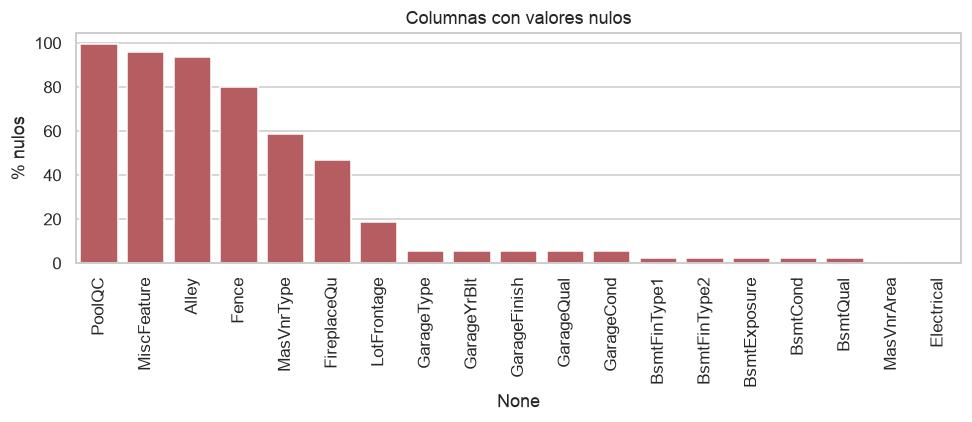

In [6]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_tbl = pd.DataFrame({
    "n_nulos": miss,
    "pct": (100 * miss / len(df)).round(1),
    "tipo": ["categórica" if c in cat_cols else "numérica" for c in miss.index],
})
display(miss_tbl)

plt.figure(figsize=(9, 4))
sns.barplot(x=miss_tbl.index, y=miss_tbl["pct"], color="#C44E52")
plt.xticks(rotation=90); plt.ylabel("% nulos"); plt.title("Columnas con valores nulos")
savefig("02_missing_values.png")
plt.show()

**Respuesta / interpretación clave.** No todos los `NA` son datos faltantes. Según la
documentación del dataset Ames, en muchas columnas **`NA` codifica la _ausencia_ de la
característica**, no un valor desconocido:

| Columna(s) | Significado real del `NA` |
|---|---|
| `PoolQC` (99.5%) | la casa **no tiene piscina** |
| `MiscFeature` (96%), `Alley` (94%), `Fence` (80%) | no hay esa característica |
| `FireplaceQu` (47%) | no hay chimenea |
| `Garage*` (5.5%) | no hay garaje |
| `Bsmt*` (2.4%) | no hay sótano |

Estas se imputarán con una **categoría explícita `"None"`** (no se eliminan: la ausencia
es informativa). En cambio, sí son nulos "reales" y se imputan por **mediana**:
`LotFrontage` (18.6%), `GarageYrBlt`, `MasVnrArea` y `Electrical` (1 dato).

### 3.2 Valores atípicos (outliers)

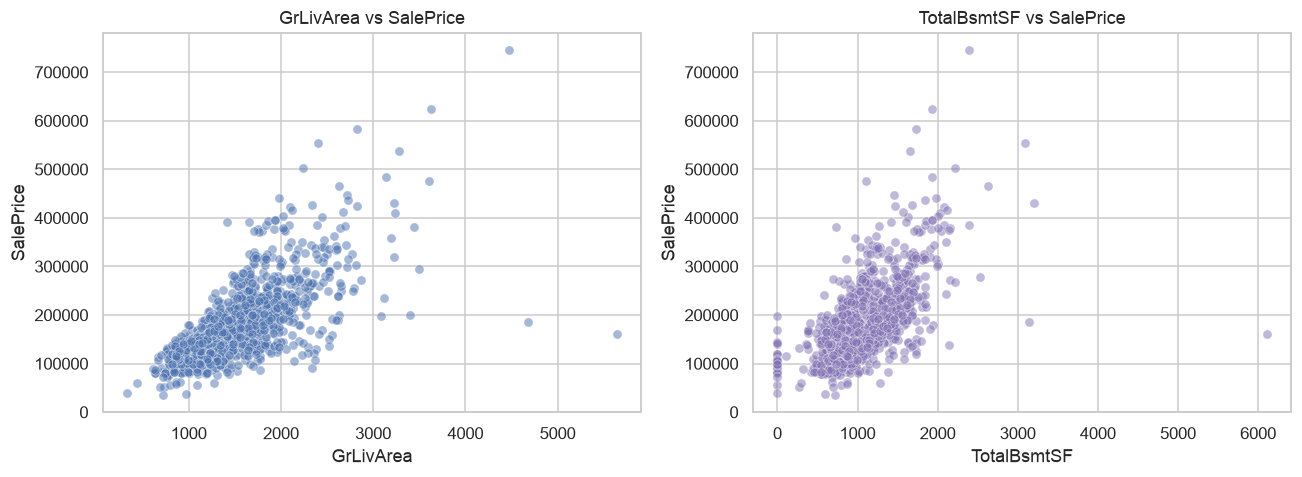

Outliers GrLivArea>4000 & SalePrice<300k: 2 filas -> Ids [524, 1299]


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"], alpha=0.5, ax=ax[0], color="#4C72B0")
ax[0].set_title("GrLivArea vs SalePrice")
sns.scatterplot(x=df["TotalBsmtSF"], y=df["SalePrice"], alpha=0.5, ax=ax[1], color="#8172B3")
ax[1].set_title("TotalBsmtSF vs SalePrice")
savefig("03_outliers_scatter.png")
plt.show()

# Casas grandes vendidas a precio anormalmente bajo (outliers conocidos de Ames)
outliers = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]
print(f"Outliers GrLivArea>4000 & SalePrice<300k: {len(outliers)} filas -> Ids {outliers['Id'].tolist()}")

**Respuesta.** El scatter `GrLivArea` vs `SalePrice` muestra una relación positiva
clara, pero hay **casas muy grandes (>4000 pies²) vendidas a precio anormalmente bajo**
— los outliers documentados del dataset Ames (ventas parciales/atípicas). Son muy pocos.

> **Decisión:** se consideran para posible eliminación en la fase de entrenamiento, pero
> como el objetivo se transforma con `log1p` (que comprime la cola) y el conjunto es
> pequeño, evaluaremos su impacto empíricamente antes de descartar filas.

## 4. Visualizaciones de correlaciones y relaciones con el objetivo

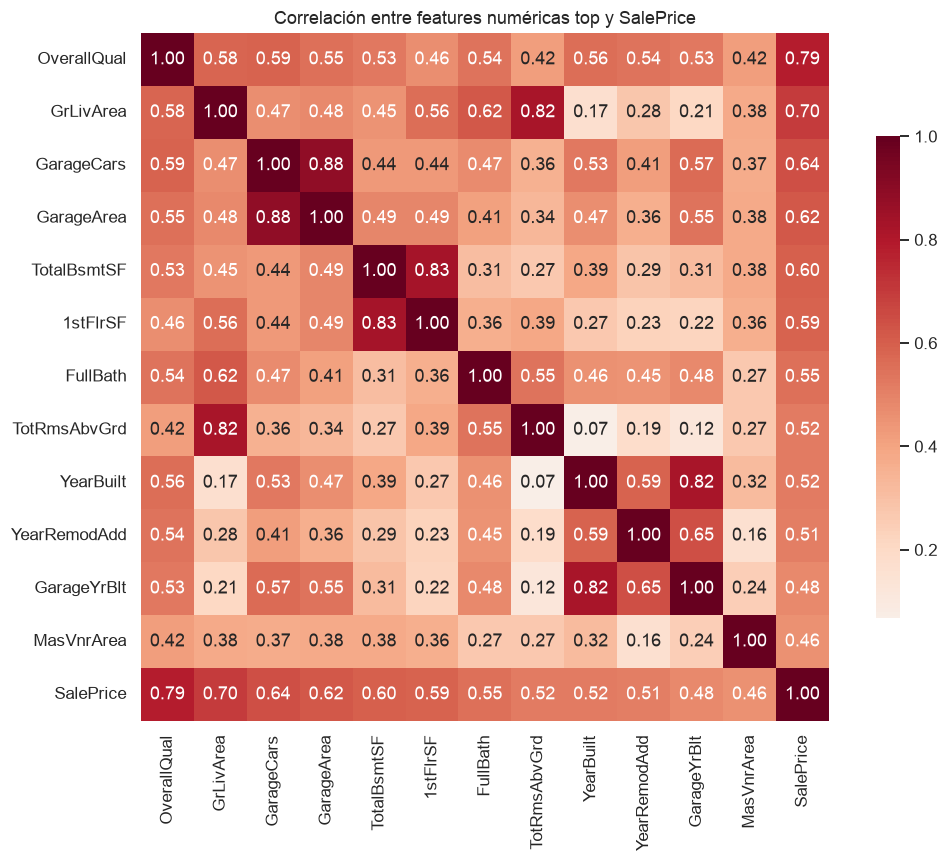

In [8]:
# Heatmap de correlaciones entre las numéricas más relevantes y el target
top_corr_cols = corr_target.head(12).index.tolist() + ["SalePrice"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, cbar_kws={"shrink": .7})
plt.title("Correlación entre features numéricas top y SalePrice")
savefig("04_corr_heatmap.png")
plt.show()

/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_99813/2628755271.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_plot.values, y=corr_plot.index, palette="vlag", ax=ax)


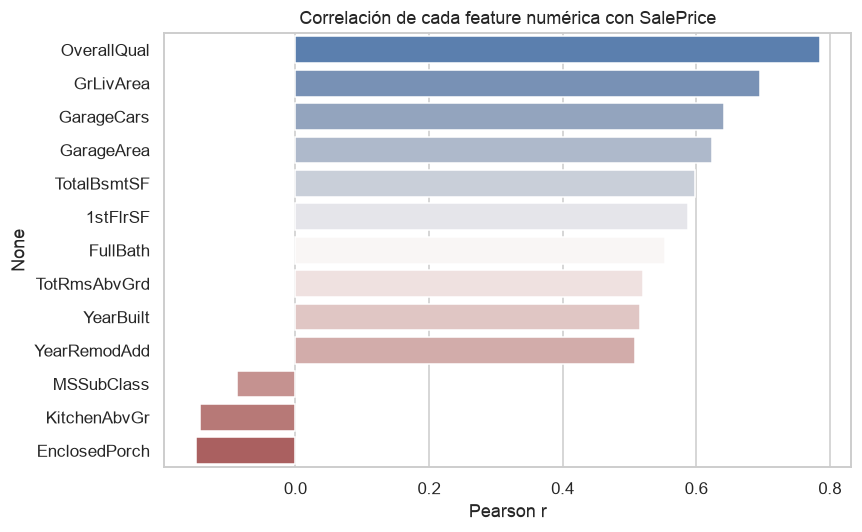

In [9]:
# Top-10 correlaciones (positivas y negativas) con SalePrice
fig, ax = plt.subplots(figsize=(8, 5))
corr_plot = pd.concat([corr_target.head(10), corr_target.tail(3)])
sns.barplot(x=corr_plot.values, y=corr_plot.index, palette="vlag", ax=ax)
ax.set_title("Correlación de cada feature numérica con SalePrice")
ax.set_xlabel("Pearson r")
savefig("05_corr_target_bars.png")
plt.show()

/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_99813/1071744637.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["OverallQual"], y=df["SalePrice"], ax=ax[0], palette="viridis")
/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_99813/1071744637.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["GarageCars"], y=df["SalePrice"], ax=ax[2], palette="mako")


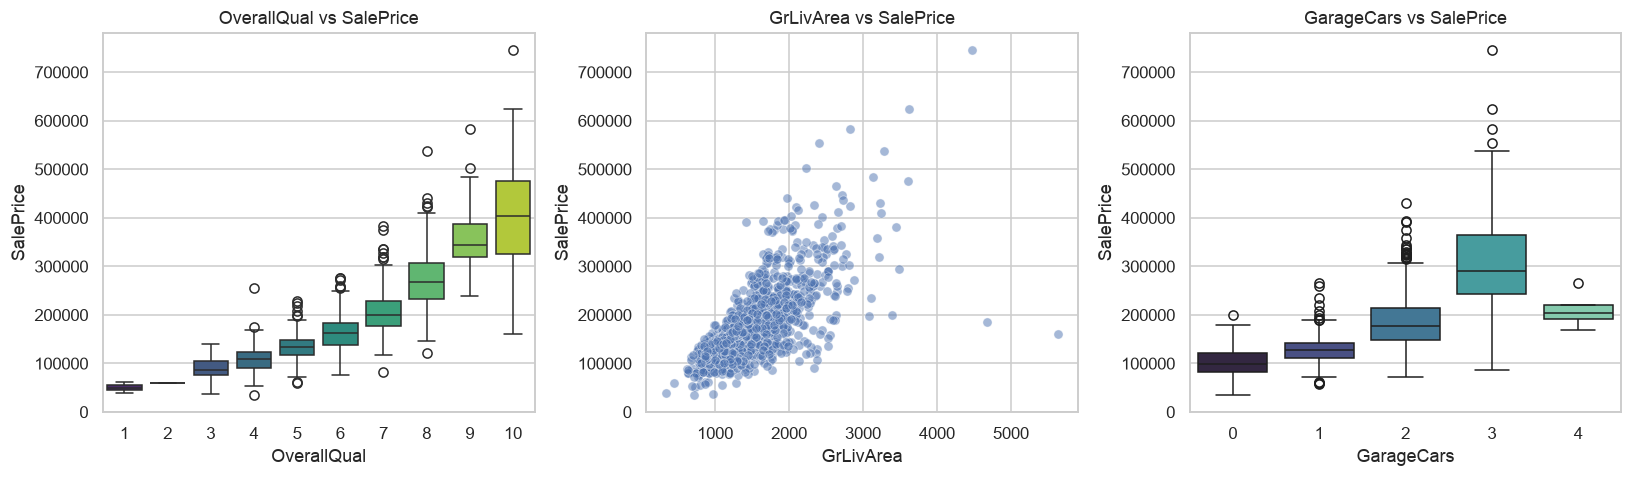

In [10]:
# Relación de features clave con el objetivo
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(x=df["OverallQual"], y=df["SalePrice"], ax=ax[0], palette="viridis")
ax[0].set_title("OverallQual vs SalePrice")
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"], alpha=0.5, ax=ax[1], color="#4C72B0")
ax[1].set_title("GrLivArea vs SalePrice")
sns.boxplot(x=df["GarageCars"], y=df["SalePrice"], ax=ax[2], palette="mako")
ax[2].set_title("GarageCars vs SalePrice")
savefig("06_features_vs_target.png")
plt.show()

**Respuesta.** Las features más asociadas al precio son, en orden:
**`OverallQual`** (r = 0.79, calidad general de materiales/acabados), **`GrLivArea`**
(r = 0.70, área habitable), **`GarageCars`/`GarageArea`** (r ≈ 0.63) y **`TotalBsmtSF`**
(r = 0.60). Todas tienen sentido de dominio: calidad, tamaño y capacidad de garaje
mandan sobre el precio. Se observa **multicolinealidad** esperable entre pares como
`GarageCars`–`GarageArea` y `TotRmsAbvGrd`–`GrLivArea` (miden lo mismo). El MLP tolera
la colinealidad, así que no eliminamos features por esa razón, pero lo notamos para la
discusión.

## 5. Decisiones de preprocesamiento derivadas del EDA

A partir del análisis anterior, el pipeline de preprocesamiento (implementado en
`mlp_core.build_preprocessor`, fitteado **solo con train** y serializado para reusarse
idéntico en el test) hará:

| Paso | Variables | Justificación |
|---|---|---|
| **Imputar `"None"`** | categóricas de `NA_MEANS_NONE` (piscina, sótano, garaje…) | el `NA` es ausencia real de la característica, información útil |
| **Imputar mediana** | numéricas con nulos (`LotFrontage`, `GarageYrBlt`, `MasVnrArea`) | robusta ante la asimetría |
| **`StandardScaler`** | todas las numéricas | escalas muy dispares (0–10 vs miles de pies²); el MLP entrena mejor con features normalizadas |
| **`OneHotEncoder(handle_unknown="ignore")`** | todas las categóricas | cardinalidad manejable; `ignore` tolera categorías no vistas en el test del día de la presentación |
| **`log1p` en el target** | `SalePrice` | corrige la asimetría (skew 1.74 → 0.13); se invierte con `expm1` al predecir |

Con esto cerramos el EDA. Las siguientes secciones construyen el preprocesamiento,
definen el MLP y documentan las iteraciones de entrenamiento.

## 6. Metodología: preparación de datos para el MLP

Siguiendo las decisiones del EDA construimos el pipeline de preprocesamiento con
`mlp_core.build_preprocessor` (un `ColumnTransformer` de scikit-learn). Puntos clave:

- **División train / validación / test = 70 / 15 / 15** (semilla fija). El *test*
  interno es un *held-out* que **no** se usa para elegir hiperparámetros; sirve para
  estimar de forma honesta el RMSE esperable en el dataset de prueba real.
- El preprocesador se **fitea solo con el split de entrenamiento** → sin *data leakage*.
- El objetivo se transforma con **`log1p`** (sección 1.2) y luego se **estandariza**
  (media 0, desviación 1) usando la media/std del *train*. Estandarizar el objetivo
  mantiene la pérdida en una escala estable y hace comparables las iteraciones; al
  predecir se invierte la cadena completa: `y = expm1(z·std + mean)`.

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import mlp_core
from mlp_core import prefill_na_none, build_preprocessor, MLP, rmse

# --- Reproducibilidad y device ---
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", device)

# --- NA = 'None' en las categóricas de ausencia, y separación X / y ---
data = prefill_na_none(df)
X_all = data.drop(columns=["Id", "SalePrice"])
y_usd = data["SalePrice"].values.astype(np.float64)   # dólares (para evaluación)
y_log = np.log1p(y_usd)                                # log-objetivo

# --- Split 70/15/15 ---
idx = np.arange(len(X_all))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30, random_state=SEED)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)
print(f"train={len(idx_tr)}  val={len(idx_val)}  test={len(idx_te)}")

# --- Estandarización del objetivo (parámetros SOLO de train) ---
y_log_mean = float(y_log[idx_tr].mean())
y_log_std  = float(y_log[idx_tr].std())
def y_to_z(y_log_arr):  return ((y_log_arr - y_log_mean) / y_log_std).astype(np.float32)
def z_to_usd(z):        return np.expm1(z * y_log_std + y_log_mean)
print(f"log-target  mean={y_log_mean:.4f}  std={y_log_std:.4f}")

PyTorch: 2.13.0 | device: cpu
train=817  val=175  test=176
log-target  mean=12.0355  std=0.3879


In [12]:
# --- Fit del preprocesador SOLO con train, transform a los tres splits ---
preprocessor, num_cols_p, cat_cols_p = build_preprocessor(data)
X_tr  = preprocessor.fit_transform(X_all.iloc[idx_tr])
X_val = preprocessor.transform(X_all.iloc[idx_val])
X_te  = preprocessor.transform(X_all.iloc[idx_te])
n_features = X_tr.shape[1]
print(f"Features tras One-Hot: {n_features}  (num={len(num_cols_p)}, cat={len(cat_cols_p)})")

def to_t(a): return torch.tensor(np.asarray(a, dtype=np.float32))
Xtr_t, Xval_t, Xte_t = to_t(X_tr), to_t(X_val), to_t(X_te)
ztr_t  = to_t(y_to_z(y_log[idx_tr]))
zval_t = to_t(y_to_z(y_log[idx_val]))
zte_t  = to_t(y_to_z(y_log[idx_te]))

# dólares reales para el RMSE de competencia
y_tr_usd, y_val_usd, y_te_usd = y_usd[idx_tr], y_usd[idx_val], y_usd[idx_te]

train_ds = TensorDataset(Xtr_t, ztr_t)
print("Listo. X_train:", tuple(Xtr_t.shape))

Features tras One-Hot: 296  (num=36, cat=43)
Listo. X_train: (817, 296)


## 7. Modelo, entrenamiento y evaluación

Reutilizamos `mlp_core.MLP` (MLP configurable con BatchNorm/Dropout). Las funciones de
entrenamiento siguen el patrón de mis laboratorios previos: reciben un `config`
(diccionario de hiperparámetros), aplican **early stopping** sobre la pérdida de
validación y devuelven el historial de curvas.

- **Pérdida:** `MSELoss` sobre el objetivo estandarizado `z`.
- **Optimizador:** Adam con `weight_decay` (L2) configurable.
- **Regularización:** Dropout, BatchNorm, weight decay y early stopping.
- **Métrica reportada:** RMSE en **dólares** (se invierte `z → USD`), la métrica de la
  competencia.

In [13]:
def build_optimizer(model, config):
    lr = config.get("lr", 1e-3); wd = config.get("weight_decay", 0.0)
    name = config.get("optimizer", "adam")
    if name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    if name == "rmsprop":
        return torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=wd)
    return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)


def train_model(config, n_features, verbose=False):
    """Entrena un MLP según `config`. Devuelve (best_model, history).

    Early stopping: conserva los pesos con menor val_loss y detiene si no mejora en
    `patience` epochs. history = {'train_loss', 'val_loss'} en MSE del objetivo z.
    """
    set_seed(SEED)
    model = MLP(n_features,
                hidden_layers=config["hidden_layers"],
                activation=config.get("activation", "relu"),
                dropout=config.get("dropout", 0.0),
                batchnorm=config.get("batchnorm", True)).to(device)
    criterion = nn.MSELoss()
    optimizer = build_optimizer(model, config)
    epochs = config.get("epochs", 300)
    patience = config.get("patience", 30)
    batch_size = config.get("batch_size", 64)

    g = torch.Generator().manual_seed(SEED)
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)
    Xv, zv = Xval_t.to(device), zval_t.to(device)

    history = {"train_loss": [], "val_loss": []}
    best_val, best_state, bad = float("inf"), None, 0
    for epoch in range(epochs):
        model.train(); running = 0.0
        for xb, zb in loader:
            xb, zb = xb.to(device), zb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), zb)
            loss.backward(); optimizer.step()
            running += loss.item() * xb.size(0)
        tr_loss = running / len(train_ds)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(Xv), zv).item()
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                if verbose: print(f"  early stop @ epoch {epoch} (val_loss={best_val:.4f})")
                break
    model.load_state_dict(best_state)
    return model, history


def eval_rmse_usd(model, X_t, y_usd_true):
    """RMSE en dólares: invierte z -> USD con z_to_usd."""
    model.eval()
    with torch.no_grad():
        z_pred = model(X_t.to(device)).cpu().numpy()
    return rmse(y_usd_true, z_to_usd(z_pred))


def plot_history(history, title="", ax=None):
    ax = ax or plt.gca()
    ax.plot(history["train_loss"], label="train")
    ax.plot(history["val_loss"], label="val")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE (z estandarizado)")
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)

## 8. Iteraciones: búsqueda de hiperparámetros

Documentamos una serie de iteraciones, cada una cambiando **un aspecto** respecto a la
anterior (profundidad/ancho, BatchNorm, dropout, weight decay, learning rate). Para cada
una registramos el **RMSE de train y validación** en dólares; el *test* interno se
reserva para la evaluación final. Corresponde a la sección 2.3 de la rúbrica.

In [14]:
configs = [
    {"name": "it1_baseline",  "hidden_layers": [64],           "dropout": 0.0, "batchnorm": False, "weight_decay": 0.0,  "lr": 1e-3},
    {"name": "it2_deeper",    "hidden_layers": [128, 64],      "dropout": 0.0, "batchnorm": False, "weight_decay": 0.0,  "lr": 1e-3},
    {"name": "it3_batchnorm", "hidden_layers": [128, 64],      "dropout": 0.0, "batchnorm": True,  "weight_decay": 0.0,  "lr": 1e-3},
    {"name": "it4_dropout",   "hidden_layers": [128, 64],      "dropout": 0.3, "batchnorm": True,  "weight_decay": 0.0,  "lr": 1e-3},
    {"name": "it5_wdecay",    "hidden_layers": [128, 64],      "dropout": 0.3, "batchnorm": True,  "weight_decay": 1e-4, "lr": 1e-3},
    {"name": "it6_wider",     "hidden_layers": [256, 128],     "dropout": 0.3, "batchnorm": True,  "weight_decay": 1e-4, "lr": 1e-3},
    {"name": "it7_deep3",     "hidden_layers": [256, 128, 64], "dropout": 0.3, "batchnorm": True,  "weight_decay": 1e-4, "lr": 1e-3},
    {"name": "it8_lowlr",     "hidden_layers": [256, 128],     "dropout": 0.2, "batchnorm": True,  "weight_decay": 1e-4, "lr": 5e-4},
]
for c in configs:
    c.setdefault("epochs", 400); c.setdefault("patience", 40); c.setdefault("batch_size", 64)

results, histories, models = [], {}, {}
for c in configs:
    model, hist = train_model(c, n_features, verbose=True)
    models[c["name"]] = model
    histories[c["name"]] = hist
    rmse_tr  = eval_rmse_usd(model, Xtr_t,  y_tr_usd)
    rmse_val = eval_rmse_usd(model, Xval_t, y_val_usd)
    results.append({"iteración": c["name"],
                    "arquitectura": "-".join(map(str, c["hidden_layers"])),
                    "dropout": c["dropout"], "batchnorm": c["batchnorm"],
                    "weight_decay": c["weight_decay"], "lr": c["lr"],
                    "epochs_ran": len(hist["train_loss"]),
                    "RMSE_train": round(rmse_tr, 1), "RMSE_val": round(rmse_val, 1)})
    print(f"{c['name']:16s}  RMSE_train={rmse_tr:9.1f}  RMSE_val={rmse_val:9.1f}")

  early stop @ epoch 51 (val_loss=0.0891)
it1_baseline      RMSE_train=  19072.4  RMSE_val=  28280.7


  early stop @ epoch 47 (val_loss=0.0913)
it2_deeper        RMSE_train=  18325.8  RMSE_val=  29479.4


  early stop @ epoch 68 (val_loss=0.1142)
it3_batchnorm     RMSE_train=   6664.9  RMSE_val=  30441.6


  early stop @ epoch 72 (val_loss=0.0913)
it4_dropout       RMSE_train=  11399.5  RMSE_val=  28030.4


  early stop @ epoch 56 (val_loss=0.0909)
it5_wdecay        RMSE_train=  16562.5  RMSE_val=  29092.4


  early stop @ epoch 72 (val_loss=0.0924)
it6_wider         RMSE_train=   8620.9  RMSE_val=  29577.4


  early stop @ epoch 109 (val_loss=0.0839)
it7_deep3         RMSE_train=   9511.8  RMSE_val=  25413.9


  early stop @ epoch 100 (val_loss=0.0916)
it8_lowlr         RMSE_train=   6521.5  RMSE_val=  28925.1


### 8.1 Tabla resumen de iteraciones

In [15]:
res_df = pd.DataFrame(results).sort_values("RMSE_val").reset_index(drop=True)
res_df.to_csv("../reports/iteraciones.csv", index=False)
display(res_df)

best_name = res_df.iloc[0]["iteración"]
best_config = next(c for c in configs if c["name"] == best_name)
print(f"\nMejor iteración por RMSE de validación: {best_name} "
      f"(RMSE_val = {res_df.iloc[0]['RMSE_val']:.1f})")

,iteración,arquitectura,dropout,batchnorm,weight_decay,lr,epochs_ran,RMSE_train,RMSE_val
0,it7_deep3,256-128-64,0.3,True,0.0001,0.0010,110,9511.8,25413.9
1,it4_dropout,128-64,0.3,True,0.0000,0.0010,73,11399.5,28030.4
2,it1_baseline,64,0.0,False,0.0000,0.0010,52,19072.4,28280.7
3,it8_lowlr,256-128,0.2,True,0.0001,0.0005,101,6521.5,28925.1
4,it5_wdecay,128-64,0.3,True,0.0001,0.0010,57,16562.5,29092.4
5,it2_deeper,128-64,0.0,False,0.0000,0.0010,48,18325.8,29479.4
6,it6_wider,256-128,0.3,True,0.0001,0.0010,73,8620.9,29577.4
7,it3_batchnorm,128-64,0.0,True,0.0000,0.0010,69,6664.9,30441.6



Mejor iteración por RMSE de validación: it7_deep3 (RMSE_val = 25413.9)


### 8.2 Curvas de aprendizaje (train vs. validación)

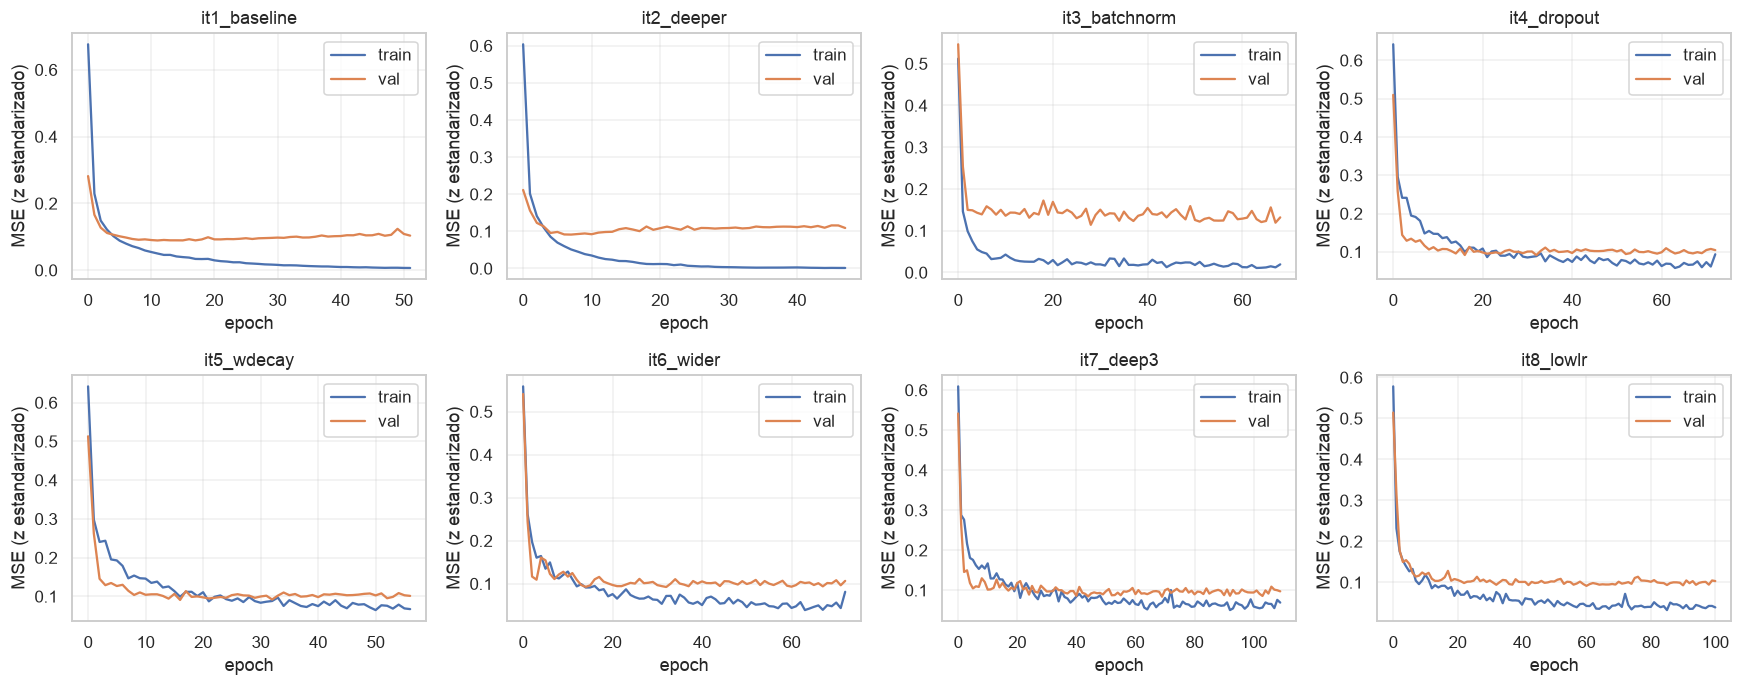

In [16]:
n = len(configs); ncol = 4; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol, 3.2*nrow))
for ax, c in zip(axes.ravel(), configs):
    plot_history(histories[c["name"]], title=c["name"], ax=ax)
for ax in axes.ravel()[n:]:
    ax.axis("off")
savefig("07_learning_curves.png")
plt.show()

**Lectura de las curvas.** Con el objetivo estandarizado las iteraciones son
comparables y el efecto de cada cambio se lee con claridad: añadir profundidad y
**BatchNorm** acelera y estabiliza el descenso; **Dropout + weight decay** reducen la
brecha train/val (menos overfitting). La iteración ganadora (tabla 8.1) se selecciona
como configuración final, se evalúa sobre el *test* interno y luego se reentrena sobre
todos los datos para la competencia (sección 9).